
C1 equation pool (deduped)
--------------------------
000: + cutter.h - 6 = + 0
001: + cutter.h - 2*cutter.y = + 0
002: + cutter.h - 2*cutter.y - pizza.h + 2*pizza.y - 2 = + 0
003: + cutter.h - cutter.y - 3 = + 0
004: + cutter.h - cutter.y - pizza.h + pizza.y - 2 = + 0
005: + cutter.h - cutter.y + pizza.y - 6 = + 0
006: + cutter.w - 1 = + 0
007: + cutter.w + cutter.x + 3 = + 0
008: + cutter.w + cutter.x - pizza.w - pizza.x + 4 = + 0
009: + cutter.w + cutter.x - pizza.x + 1 = + 0
010: + cutter.w + 2*cutter.x + 7 = + 0
011: + cutter.w + 2*cutter.x - pizza.w - 2*pizza.x + 6 = + 0
012: + cutter.x + 4 = + 0
013: + cutter.x - pizza.w - pizza.x + 5 = + 0
014: + cutter.x - pizza.x + 2 = + 0
015: + cutter.y - 3 = + 0
016: + cutter.y + pizza.h - pizza.y - 4 = + 0
017: + cutter.y - pizza.y = + 0
018: + pizza.h - 4 = + 0
019: + pizza.h - 2*pizza.y + 2 = + 0
020: + pizza.h - pizza.y - 1 = + 0
021: + pizza.w - 3 = + 0
022: + pizza.w + pizza.x - 1 = + 0
023: + pizza.w + 2*pizza.x + 1 = + 0
024: + pi

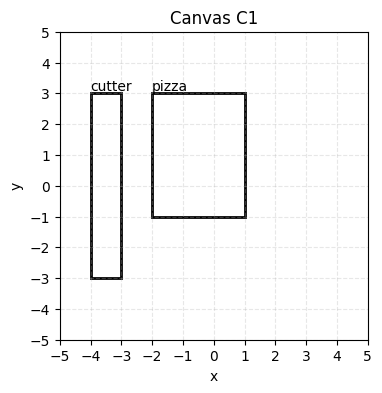

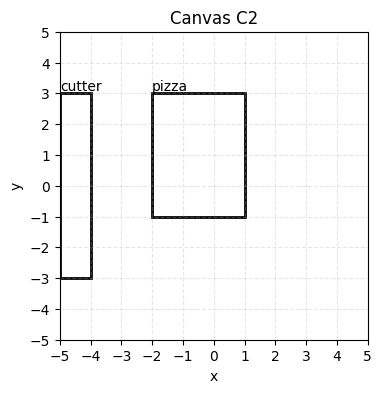

In [ ]:
"""
Prototype: detect "reasonable" exact-equality relations among axis-aligned rectangles.
"""

from __future__ import annotations

from dataclasses import dataclass
from fractions import Fraction
from itertools import combinations
from typing import Dict, Iterable, List, Tuple, Union, Optional
import math

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle as MplRect

import time
from contextlib import contextmanager

@contextmanager
def timer(label: str, bucket: Dict[str, float]):
    t0 = time.perf_counter()
    yield
    bucket[label] = bucket.get(label, 0.0) + (time.perf_counter() - t0)

Number = Union[int, float, Fraction]


# -----------------------------
# Geometry input
# -----------------------------
@dataclass(frozen=True)
class Rect:
    """Axis-aligned rectangle parameterized by (x, y, w, h) where (x,y) is top-left."""
    x: Number
    y: Number
    w: Number
    h: Number


@dataclass(frozen=True)
class NamedRect:
    name: str
    rect: Rect


# -----------------------------
# Symbolic expressions
# -----------------------------
@dataclass(frozen=True)
class Var:
    """A low-level parameter variable like 'pizza.x'."""
    name: str  # e.g., "pizza.x"


@dataclass(frozen=True)
class LinExpr:
    """
    Linear expression: sum_i coeff[var_i] * var_i + const

    Coefficients and constants stored as Fractions for exact canonicalization.
    """
    coeffs: Tuple[Tuple[str, Fraction], ...]  # sorted (var_name, coeff)
    const: Fraction = Fraction(0)

    @staticmethod
    def from_terms(terms: Dict[str, Fraction], const: Fraction = Fraction(0)) -> "LinExpr":
        # drop zero terms and sort
        cleaned = [(k, v) for k, v in terms.items() if v != 0]
        cleaned.sort(key=lambda kv: kv[0])
        return LinExpr(coeffs=tuple(cleaned), const=const)

    @staticmethod
    def var(v: Var, coeff: Fraction = Fraction(1), const: Fraction = Fraction(0)) -> "LinExpr":
        return LinExpr.from_terms({v.name: coeff}, const)

    @staticmethod
    def const(c: Number) -> "LinExpr":
        return LinExpr.from_terms({}, _to_frac(c))

    def vars(self) -> Tuple[str, ...]:
        return tuple(k for k, _ in self.coeffs)

    def __add__(self, other: "LinExpr") -> "LinExpr":
        terms: Dict[str, Fraction] = dict(self.coeffs)
        for k, v in other.coeffs:
            terms[k] = terms.get(k, Fraction(0)) + v
        return LinExpr.from_terms(terms, self.const + other.const)

    def __sub__(self, other: "LinExpr") -> "LinExpr":
        terms: Dict[str, Fraction] = dict(self.coeffs)
        for k, v in other.coeffs:
            terms[k] = terms.get(k, Fraction(0)) - v
        return LinExpr.from_terms(terms, self.const - other.const)

    def __mul__(self, scalar: Number) -> "LinExpr":
        s = _to_frac(scalar)
        terms = {k: v * s for k, v in self.coeffs}
        return LinExpr.from_terms(terms, self.const * s)

    def __rmul__(self, scalar: Number) -> "LinExpr":
        return self.__mul__(scalar)

    def is_zero(self) -> bool:
        return len(self.coeffs) == 0 and self.const == 0

    def pretty(self) -> str:
        # pretty print like: 1*pizza.x + 1/2*pizza.w - 3
        parts: List[str] = []
        for var, c in self.coeffs:
            parts.append(_pretty_term(c, var))
        if self.const != 0 or not parts:
            parts.append(_pretty_const(self.const))
        # clean leading "+ "
        s = " ".join(parts)
        s = s.replace("+ -", "- ")
        return s


@dataclass(frozen=True)
class PolyExpr:
    """
    Limited polynomial expression used for area: w*h.
    We keep it symbolic as (w_var * h_var) only, plus linear terms if desired later.
    For now: either a LinExpr OR a single product term.

    kind:
      - 'lin' : linear expression
      - 'mul' : product of two Vars (commutative canonical order)
    """
    kind: str
    lin: Optional[LinExpr] = None
    mul_vars: Optional[Tuple[str, str]] = None  # (varA, varB) sorted

    @staticmethod
    def linexpr(le: LinExpr) -> "PolyExpr":
        return PolyExpr(kind="lin", lin=le)

    @staticmethod
    def mul(v1: Var, v2: Var) -> "PolyExpr":
        a, b = sorted([v1.name, v2.name])
        return PolyExpr(kind="mul", mul_vars=(a, b))

    def vars(self) -> Tuple[str, ...]:
        if self.kind == "lin":
            assert self.lin is not None
            return self.lin.vars()
        assert self.mul_vars is not None
        return self.mul_vars

    def pretty(self) -> str:
        if self.kind == "lin":
            assert self.lin is not None
            return self.lin.pretty()
        assert self.mul_vars is not None
        return f"{self.mul_vars[0]} * {self.mul_vars[1]}"

    def canonical_key(self) -> Tuple:
        if self.kind == "lin":
            assert self.lin is not None
            # Normalize linear expressions for stable equality comparisons
            return ("lin", _canonical_lin_key(self.lin))
        assert self.mul_vars is not None
        return ("mul", self.mul_vars)


@dataclass(frozen=True)
class Equation:
    """Equation of the form left == right."""
    left: PolyExpr
    right: PolyExpr

    def pretty(self) -> str:
        return f"{self.left.pretty()} = {self.right.pretty()}"

    def vars(self) -> Tuple[str, ...]:
        return tuple(sorted(set(self.left.vars()) | set(self.right.vars())))

    def canonical(self) -> "Equation":
        """
        Canonicalize the equation for deduping:
        - If both sides are linear: move to one side and normalize to a canonical (lin == 0)
        - If both sides are mul terms: sort sides lexicographically (commutative equality)
        - If mixed kinds: sort by key
        """
        lk = self.left.canonical_key()
        rk = self.right.canonical_key()

        # linear == linear -> normalize (L - R == 0)
        if lk[0] == "lin" and rk[0] == "lin":
            L = self.left.lin
            R = self.right.lin
            assert L is not None and R is not None
            diff = L - R
            diff_norm = _normalize_lin_to_canonical(diff)  # diff_norm == 0
            return Equation(PolyExpr.linexpr(diff_norm), PolyExpr.linexpr(LinExpr.const(0)))

        # mul == mul -> commutative equality
        if lk[0] == "mul" and rk[0] == "mul":
            if lk <= rk:
                return self
            return Equation(self.right, self.left)

        # mixed: enforce ordering by canonical key
        if lk <= rk:
            return self
        return Equation(self.right, self.left)


# -----------------------------
# Helpers: Fractions + printing
# -----------------------------
def _to_frac(x: Number) -> Fraction:
    if isinstance(x, Fraction):
        return x
    if isinstance(x, int):
        return Fraction(x, 1)
    if isinstance(x, float):
        # Convert float to fraction in a stable way; for exact-equality prototyping
        # it's better to avoid floats, but we support them.
        return Fraction.from_float(x).limit_denominator(10_000)
    raise TypeError(f"Unsupported number type: {type(x)}")


def _pretty_term(c: Fraction, var: str) -> str:
    if c == 1:
        return f"+ {var}"
    if c == -1:
        return f"- {var}"
    return f"+ {c}*{var}" if c > 0 else f"- {abs(c)}*{var}"


def _pretty_const(c: Fraction) -> str:
    if c == 0:
        return "+ 0"
    return f"+ {c}" if c > 0 else f"- {abs(c)}"


def _canonical_lin_key(le: LinExpr) -> Tuple:
    return (le.coeffs, le.const)


def _normalize_lin_to_canonical(le: LinExpr) -> LinExpr:
    """
    Normalize linear expression to a canonical representative of the equivalence class
    le == 0 under scaling by nonzero constant.

    Steps:
    - If all coeffs are 0 and const is 0: keep 0.
    - Scale so that leading (lexicographically smallest var) coefficient is positive.
    - Divide by gcd of integerized coefficients/const after clearing denominators.
    """
    if le.is_zero():
        return le

    # Find first nonzero coefficient as pivot
    coeffs = list(le.coeffs)
    # Build list of all fractions to normalize
    fracs = [c for _, c in coeffs] + [le.const]
    denoms = [f.denominator for f in fracs if f != 0]
    lcm_den = 1
    for d in denoms:
        lcm_den = lcm_den * d // math.gcd(lcm_den, d)

    # Integerize
    int_terms: Dict[str, int] = {k: int(v * lcm_den) for k, v in coeffs}
    int_const = int(le.const * lcm_den)

    # gcd across all integers (abs)
    all_ints = [abs(v) for v in int_terms.values() if v != 0] + ([abs(int_const)] if int_const != 0 else [])
    g = 0
    for v in all_ints:
        g = v if g == 0 else math.gcd(g, v)
    if g == 0:
        g = 1

    # Reduce
    int_terms = {k: v // g for k, v in int_terms.items()}
    int_const //= g

    # Ensure pivot positive
    # pivot is the first nonzero coefficient by var order
    pivot_var = None
    pivot_val = None
    for k in sorted(int_terms.keys()):
        if int_terms[k] != 0:
            pivot_var, pivot_val = k, int_terms[k]
            break
    if pivot_var is not None and pivot_val is not None and pivot_val < 0:
        int_terms = {k: -v for k, v in int_terms.items()}
        int_const = -int_const

    # Convert back to Fractions
    terms_frac = {k: Fraction(v, 1) for k, v in int_terms.items()}
    return LinExpr.from_terms(terms_frac, Fraction(int_const, 1))

# === NEW HELPERS: build fixed-constant offset equations from C1 ===

def poly_to_linexpr(pe: PolyExpr) -> LinExpr | None:
    """Return the LinExpr if PolyExpr is linear; else None (e.g., area mul)."""
    if pe.kind == "lin":
        return pe.lin
    return None

def linexpr_plus_const(le: LinExpr, c: Fraction) -> LinExpr:
    """Return le + c."""
    return LinExpr.from_terms(dict(le.coeffs), le.const + c)

def make_offset_equation_from_c1(left: PolyExpr, right: PolyExpr, c1_env: dict[str, Fraction]) -> Equation | None:
    """
    Create an equation instance enforcing the C1 offset:
      left - right = d  where d = left(C1) - right(C1)
    Represented as: left == right + d   (all constants fixed numbers).
    Only works for linear expressions.
    """
    L = poly_to_linexpr(left)
    R = poly_to_linexpr(right)
    if L is None or R is None:
        return None

    d = eval_linexpr(L, c1_env) - eval_linexpr(R, c1_env)  # fixed constant from C1
    # left == right + d
    return Equation(left, PolyExpr.linexpr(linexpr_plus_const(R, d)))

def make_pin_equation_from_c1(expr: PolyExpr, c1_env: dict[str, Fraction]) -> Equation | None:
    """
    Pin schema: expr = K
    Instance: K := expr(C1) (a literal constant), and emit expr = K.
    Works for linear expr only.
    """
    L = poly_to_linexpr(expr)
    if L is None:
        return None
    k = eval_linexpr(L, c1_env)
    const_expr = PolyExpr.linexpr(LinExpr.from_terms({}, k))
    return Equation(expr, const_expr)


def generate_pin_equations(rects: List[NamedRect], feats: dict[str, dict[str, PolyExpr]], c1_env: dict[str, Fraction]) -> List[Equation]:
    """
    Emit both 'simple' and 'compound' pins as C1 relations.
    Keep this set small to avoid explosion.
    """
    PIN_KEYS = [
        # simple pins (single-var)
        "left", "top", "width", "height",
        # compound pins (multi-var) that can be useful later
        "right", "bottom", "center_x", "center_y", "area",
    ]
    eqs: List[Equation] = []
    for nr in rects:
        f = feats[nr.name]
        for k in PIN_KEYS:
            e = make_pin_equation_from_c1(f[k], c1_env)
            if e is not None:
                eqs.append(e)
    return eqs

# -----------------------------
# Feature expressions
# -----------------------------
def rect_vars(nr: NamedRect) -> Dict[str, Var]:
    n = nr.name
    return {
        "x": Var(f"{n}.x"),
        "y": Var(f"{n}.y"),
        "w": Var(f"{n}.w"),
        "h": Var(f"{n}.h"),
    }


def feature_exprs(nr: NamedRect) -> Dict[str, PolyExpr]:
    """
    Return named feature expressions for a rectangle.

    X-axis: left, right, center_x
    Y-axis: top, bottom, center_y
    Size: width, height
    Area: width*height (multiplicative)
    """
    v = rect_vars(nr)
    x = LinExpr.var(v["x"])
    y = LinExpr.var(v["y"])
    w = LinExpr.var(v["w"])
    h = LinExpr.var(v["h"])

    feats: Dict[str, PolyExpr] = {
        "left": PolyExpr.linexpr(x),
        "right": PolyExpr.linexpr(x + w),
        "center_x": PolyExpr.linexpr(x + Fraction(1, 2) * w),

        "top": PolyExpr.linexpr(y),
        "bottom": PolyExpr.linexpr(y - h),
        "center_y": PolyExpr.linexpr(y - Fraction(1, 2) * h),

        "width": PolyExpr.linexpr(w),
        "height": PolyExpr.linexpr(h),

        "area": PolyExpr.mul(v["w"], v["h"]),
    }
    return feats


# -----------------------------
# Relation generation (equations)
# -----------------------------
def generate_equations(rects: List[NamedRect], include_offsets: bool = False, include_pins: bool = False) -> List[Equation]:
    """
    Generate a (possibly redundant) list of equations from feature equalities.

    We include:
    - For each pair of rects: equalities between x-features (left/right/center_x),
      y-features (top/bottom/center_y), width, height, and area.
    - Also include cross comparisons across x-features and y-features separately (not mixing x and y).
    """
    eqs: List[Equation] = []

    c1_env = build_env(rects) if (include_offsets or include_pins) else None

    # Precompute features
    feats = {nr.name: feature_exprs(nr) for nr in rects}

    # --- inside generate_equations, after feats computed ---

    x_keys = ["left", "right", "center_x"]
    y_keys = ["top", "bottom", "center_y"]

    # Minimal offset feature-pairs to avoid blowup but still cover spacing behavior
    OFFSET_PAIRS_X = [("left","left"), ("right","right"), ("center_x","center_x"),
                    ("left","right"), ("right","left")]
    OFFSET_PAIRS_Y = [("top","top"), ("bottom","bottom"), ("center_y","center_y"),
                    ("top","bottom"), ("bottom","top")]

    for a, b in combinations(rects, 2):
        fa = feats[a.name]
        fb = feats[b.name]

        # --- Equality relations (as before) ---
        for ka in x_keys:
            for kb in x_keys:
                eqs.append(Equation(fa[ka], fb[kb]))

        for ka in y_keys:
            for kb in y_keys:
                eqs.append(Equation(fa[ka], fb[kb]))

        # width/height/area (keep your existing lines)
        eqs.append(Equation(fa["width"], fb["width"]))
        eqs.append(Equation(fa["height"], fb["height"]))
        eqs.append(Equation(fa["area"], fb["area"]))

        # --- NEW: fixed-constant offset relations instantiated from C1 ---
        if include_offsets and c1_env is not None:
            for (ka, kb) in OFFSET_PAIRS_X:
                e = make_offset_equation_from_c1(fa[ka], fb[kb], c1_env)
                if e is not None:
                    eqs.append(e)

            for (ka, kb) in OFFSET_PAIRS_Y:
                e = make_offset_equation_from_c1(fa[ka], fb[kb], c1_env)
                if e is not None:
                    eqs.append(e)

    if include_pins and c1_env is not None:
        eqs.extend(generate_pin_equations(rects, feats, c1_env))

    return eqs

def dedupe_equations(eqs: List[Equation]) -> List[Equation]:
    """
    Canonicalize and dedupe equations.
    Returns equations in a stable sorted order by canonical key.
    """
    canon_map: Dict[Tuple, Equation] = {}
    for e in eqs:
        c = e.canonical()
        key = (c.left.canonical_key(), c.right.canonical_key())
        canon_map[key] = c  # overwrite identical
    # stable sort for printing
    items = list(canon_map.items())
    items.sort(key=lambda kv: kv[0])
    return [eq for _, eq in items]

def detect_c1_equations(
    c1: List[NamedRect],
    include_offsets: bool = True,
    include_pins: bool = True,
    linear_only: bool = True,
    print_list: bool = True,
) -> List[Equation]:
    """
    Run ONLY detection on C1 and return the deduped equation pool.
    Prints the numbered list so you can pick indices.
    """
    eq_candidates = generate_equations(c1, include_offsets=include_offsets, include_pins=include_pins)
    eq_true = filter_true_equations(eq_candidates, c1)
    eq_true_dedup = dedupe_equations(eq_true)

    if linear_only:
        eq_true_dedup = [e for e in eq_true_dedup if linear_relation_to_linexpr(e) is not None]

    if print_list:
        print_equations("C1 equation pool (deduped)", eq_true_dedup)
        print(f"\nTotal equations in pool: {len(eq_true_dedup)}")

    return eq_true_dedup

# -----------------------------
# Canvas rendering
# -----------------------------
def plot_canvas(rects: List[NamedRect], bounds: Tuple[float, float, float, float] = (0, 16, 0, 16), name: str="") -> None:
    """
    Plot rectangles on a fixed-size canvas.

    bounds = (xmin, xmax, ymin, ymax)
    Note: Matplotlib uses bottom-left coordinate as origin; your Rect is (top-left x,y).
    We'll interpret y as "top" in the same coordinate system and draw with height downward
    by converting: mpl_y = y - h (so the rectangle occupies [y-h, y]).
    """
    xmin, xmax, ymin, ymax = bounds
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(f"Canvas {name}")

    # grid for readability
    ax.set_xticks(range(int(xmin), int(xmax) + 1))
    ax.set_yticks(range(int(ymin), int(ymax) + 1))
    ax.grid(True, linestyle="--", alpha=0.3)

    for nr in rects:
        r = nr.rect
        x = float(_to_frac(r.x))
        y_top = float(_to_frac(r.y))
        w = float(_to_frac(r.w))
        h = float(_to_frac(r.h))

        # Convert top-left to matplotlib bottom-left
        y_bottom = y_top - h

        patch = MplRect((x, y_bottom), w, h, fill=False, linewidth=2)
        ax.add_patch(patch)

        # Label near top-left corner
        ax.text(x, y_top, nr.name, fontsize=10, verticalalignment="bottom", horizontalalignment="left")

    plt.show()


# -----------------------------
# Pretty printing
# -----------------------------
def print_equations(title: str, eqs: List[Equation], max_lines: Optional[int] = None) -> None:
    print(f"\n{title}")
    print("-" * len(title))
    if max_lines is None:
        max_lines = len(eqs)
    for i, e in enumerate(eqs[:max_lines]):
        print(f"{i:03d}: {e.pretty()}")
    if max_lines < len(eqs):
        print(f"... ({len(eqs) - max_lines} more)")

from fractions import Fraction
from typing import Dict

def build_env(rects: List[NamedRect]) -> Dict[str, Fraction]:
    """Map 'pizza.x' -> value, etc."""
    env: Dict[str, Fraction] = {}
    for nr in rects:
        n = nr.name
        r = nr.rect
        env[f"{n}.x"] = _to_frac(r.x)
        env[f"{n}.y"] = _to_frac(r.y)
        env[f"{n}.w"] = _to_frac(r.w)
        env[f"{n}.h"] = _to_frac(r.h)
    return env

def eval_linexpr(le: LinExpr, env: Dict[str, Fraction]) -> Fraction:
    total = le.const
    for var, coeff in le.coeffs:
        total += coeff * env[var]
    return total

def eval_polyexpr(pe: PolyExpr, env: Dict[str, Fraction]) -> Fraction:
    if pe.kind == "lin":
        assert pe.lin is not None
        return eval_linexpr(pe.lin, env)
    assert pe.kind == "mul" and pe.mul_vars is not None
    a, b = pe.mul_vars
    return env[a] * env[b]

def equation_holds(eq: Equation, env: Dict[str, Fraction]) -> bool:
    return eval_polyexpr(eq.left, env) == eval_polyexpr(eq.right, env)

def filter_true_equations(eqs: List[Equation], rects: List[NamedRect]) -> List[Equation]:
    env = build_env(rects)
    return [e for e in eqs if equation_holds(e, env)]


"""
EXTENSION: C2-time program compilation + enumeration of C3s.
"""

from __future__ import annotations

from dataclasses import dataclass
from fractions import Fraction
from itertools import combinations
from typing import Dict, Iterable, List, Optional, Set, Tuple

# ---------- utilities from earlier script assumed present ----------
# Rect, NamedRect, LinExpr, PolyExpr, Equation
# _to_frac, build_env, eval_linexpr, eval_polyexpr, equation_holds, filter_true_equations, dedupe_equations, etc.
# If you didn't paste those evaluation helpers in yet, do so before this extension.


# -----------------------------
# C2-time: program representation
# -----------------------------
@dataclass(frozen=True)
class AffineInM:
    """An affine expression over meta-parameters: sum_j coeff[mj]*mj + const."""
    coeffs: Tuple[Tuple[str, Fraction], ...]  # sorted (mparam_name, coeff)
    const: Fraction = Fraction(0)

    @staticmethod
    def from_terms(terms: Dict[str, Fraction], const: Fraction) -> "AffineInM":
        cleaned = [(k, v) for k, v in terms.items() if v != 0]
        cleaned.sort(key=lambda kv: kv[0])
        return AffineInM(coeffs=tuple(cleaned), const=const)

    def eval(self, mvals: Dict[str, Fraction]) -> Fraction:
        total = self.const
        for k, c in self.coeffs:
            total += c * mvals[k]
        return total

    def pretty(self) -> str:
        parts: List[str] = []
        for k, c in self.coeffs:
            if c == 1:
                parts.append(f"+ {k}")
            elif c == -1:
                parts.append(f"- {k}")
            else:
                parts.append(f"+ {c}*{k}" if c > 0 else f"- {abs(c)}*{k}")
        if self.const != 0 or not parts:
            parts.append(f"+ {self.const}" if self.const > 0 else f"- {abs(self.const)}" if self.const < 0 else "+ 0")
        s = " ".join(parts).replace("+ -", "- ")
        return s

# =============================
# REWORKED PIPELINE (deterministic C3 per (E, F, parameterization))
# =============================

from dataclasses import dataclass
from itertools import combinations
from fractions import Fraction
from typing import Dict, List, Optional, Set, Tuple, Iterable

# --------- small helpers ---------

def linear_relation_to_linexpr(eq: Equation) -> Optional[LinExpr]:
    """
    If eq canonicalizes to (LinExpr == 0), return the LinExpr on the left.
    Otherwise return None (e.g., area relations).
    """
    c = eq.canonical()
    # canonical() for linear eq returns (diff_norm == 0) as lin == 0
    if c.left.kind == "lin" and c.right.kind == "lin":
        assert c.left.lin is not None and c.right.lin is not None
        # right should be const 0 after canonicalization, but we accept any linear 0.
        # We'll treat "left == right" as (left-right)==0.
        diff = c.left.lin - c.right.lin
        return diff
    return None

def _lin_system_from_equations(eqs: List[Equation]) -> Optional[Tuple[Tuple[str, ...], List[List[Fraction]], List[Fraction]]]:
    """
    Build A, rhs for A * v = rhs, where each equation is normalized as le == 0 => sum a_i v_i = -const.
    Returns (vars_sorted, A, rhs). All Fractions.
    """
    linexprs: List[LinExpr] = []
    for e in eqs:
        le = linear_relation_to_linexpr(e)
        if le is None:
            return None
        le = _normalize_lin_to_canonical(le)
        if le.is_zero():
            continue
        linexprs.append(le)

    if not linexprs:
        return None

    var_set: Set[str] = set()
    for le in linexprs:
        for v, c in le.coeffs:
            if c != 0:
                var_set.add(v)

    vars_sorted = tuple(sorted(var_set))
    if not vars_sorted:
        return None

    idx = {v: j for j, v in enumerate(vars_sorted)}
    A: List[List[Fraction]] = []
    rhs: List[Fraction] = []
    for le in linexprs:
        row = [Fraction(0) for _ in vars_sorted]
        for v, c in le.coeffs:
            row[idx[v]] = c
        A.append(row)
        rhs.append(-le.const)

    return vars_sorted, A, rhs

def build_lin_system_cached(eqs: List[Equation]) -> Optional[Tuple[Tuple[str, ...], Dict[str, int], List[List[Fraction]], List[Fraction]]]:
    """
    Build the base linear system for an equation system E once:
      vars_sorted, idx_map, A, rhs
    where A * x = rhs and rhs = -const (after canonicalization).

    This is exactly what compile_repair_program needs repeatedly for different F.
    """
    built = _lin_system_from_equations(eqs)
    if built is None:
        return None
    vars_sorted, A, rhs = built
    idx = {v: j for j, v in enumerate(vars_sorted)}
    return vars_sorted, idx, A, rhs

# --------- repaired program ---------

@dataclass(frozen=True)
class RepairProgram:
    """
    Deterministic program for *this edit*:
      - const_vars C are treated as literal constants (typically Δ∩V, pulled from C2)
      - fixed_vars F_over are the remaining fixed facts that become overridable mparams
      - driven_vars D are solved as affine functions of mparams + constants
    """
    equations: Tuple[Equation, ...]
    const_vars: Tuple[str, ...]          # C = Δ∩V, treated as literal constants
    fixed_vars: Tuple[str, ...]          # F_over = F \ C, become overridable mparams
    driven_vars: Tuple[str, ...]         # D = V \ (C ∪ F_over)
    mparams: Tuple[str, ...]             # names "m::<var>" aligned with fixed_vars
    outputs: Dict[str, AffineInM]        # for all vars in V: constant / identity / affine

    def pretty(self) -> str:
        lines = []
        lines.append("Equations:")
        for e in self.equations:
            lines.append(f"  - {e.pretty()}")

        # NEW: print Δ and full F up front, then partition
        # (Assumes const_vars == Δ∩V in your construction; still useful to show explicitly.)
        lines.append(f"Δ (changed in C1→C2): {self.const_vars}")  # if you stored full Δ elsewhere, print that too
        full_F = tuple(sorted(set(self.const_vars) | set(self.fixed_vars)))
        lines.append(f"Fixed vars F (C ∪ F'): {full_F}")

        lines.append(f"  Const vars C (Δ∩V): {self.const_vars}")
        lines.append(f"  Overridable fixed vars F': {self.fixed_vars}")
        lines.append(f"Driven vars D: {self.driven_vars}")

        lines.append("mparams (override knobs):")
        for v, m in zip(self.fixed_vars, self.mparams):
            lines.append(f"  {m}  (represents {v})")

        lines.append("outputs:")
        for v in sorted(self.outputs.keys()):
            lines.append(f"  {v} = {self.outputs[v].pretty()}")
        return "\n".join(lines)

    def apply(self, c2: List[NamedRect], mparam_overrides: Optional[Dict[str, Number]] = None) -> List[NamedRect]:
        c2_env = build_env(c2)

        # Build mvals for overridable fixed vars only
        mvals: Dict[str, Fraction] = {}
        for v, m in zip(self.fixed_vars, self.mparams):
            mvals[m] = c2_env[v]

        # Apply user overrides (only affects F', never const vars)
        if mparam_overrides:
            for k, val in mparam_overrides.items():
                if k not in mvals:
                    raise KeyError(f"Unknown/forbidden mparam '{k}'. Allowed: {sorted(mvals.keys())}")
                mvals[k] = _to_frac(val)

        # Evaluate program outputs
        updates: Dict[str, Fraction] = {}
        for v, expr in self.outputs.items():
            updates[v] = expr.eval(mvals)

        return env_to_canvas_like_c2(c2, updates)

def compile_repair_program(
    eqs: List[Equation],
    prebuilt: Tuple[Tuple[str, ...], Dict[str, int], List[List[Fraction]], List[Fraction]],
    fixed_vars: Set[str],
    const_vars: Set[str],
    const_env: Dict[str, Fraction],
) -> Optional[RepairProgram]:
    """
    Same semantics as compile_repair_program, but reuses a cached (vars_sorted, idx, A, rhs)
    and solves const+influences in one elimination via solve_linear_system_unique_multi.
    """
    vars_sorted, idx, A, rhs = prebuilt
    V = list(vars_sorted)

    C = sorted([v for v in V if v in const_vars])
    F_over = sorted([v for v in V if (v in fixed_vars) and (v not in const_vars)])
    D = [v for v in V if v not in set(C) and v not in set(F_over)]

    if len(D) == 0:
        return None

    m = len(A)
    d = len(D)

    # Necessary condition 1: can't uniquely solve more driven vars than equations
    if m < d:
        return None

    D_cols = [idx[v] for v in D]
    F_cols = [idx[v] for v in F_over]
    C_cols = [idx[v] for v in C]

    A_D = [[row[j] for j in D_cols] for row in A]

    # Necessary condition 3: any all-zero driven column => that driven var is not determined
    for j in range(len(D_cols)):
        if all(A_D[i][j] == 0 for i in range(m)):
            return None

    # Necessary condition 2: if square (m == d) we can det-check cheaply for d<=3
    if m == d:
        if det_gauss(A_D) == 0:
            return None
        # if d > 3, fall through to full elimination (rare in your max_system_size<=3 setting anyway)

    A_F = [[row[j] for j in F_cols] for row in A]
    A_C = [[row[j] for j in C_cols] for row in A]

    # rhs_adj = rhs - A_C * xC
    xC = [const_env[v] for v in C]
    rhs_adj: List[Fraction] = []
    for i in range(len(A)):
        s = rhs[i]
        for j in range(len(C)):
            s -= A_C[i][j] * xC[j]
        rhs_adj.append(s)

    # Build all RHS columns at once:
    # col0: rhs_adj
    # col(1+j): -A_F[:,j]
    Bs: List[List[Fraction]] = [rhs_adj]
    for j in range(len(F_over)):
        Bs.append([-(A_F[i][j]) for i in range(len(A_F))])

    sols = solve_linear_system(A_D, Bs)
    if sols is None:
        return None

    const_vec = sols[0]                 # length |D|
    coeff_cols = sols[1:]               # len |F_over|, each length |D|

    # Build outputs
    mparams = tuple(f"m::{v}" for v in F_over)
    outputs: Dict[str, AffineInM] = {}

    for v in C:
        outputs[v] = AffineInM.from_terms({}, const=const_env[v])

    for v, m in zip(F_over, mparams):
        outputs[v] = AffineInM.from_terms({m: Fraction(1)}, const=Fraction(0))

    for i, v in enumerate(D):
        terms: Dict[str, Fraction] = {}
        for j, m in enumerate(mparams):
            c = coeff_cols[j][i]
            if c != 0:
                terms[m] = c
        outputs[v] = AffineInM.from_terms(terms, const=const_vec[i])

    return RepairProgram(
        equations=tuple(eqs),
        const_vars=tuple(C),
        fixed_vars=tuple(F_over),
        driven_vars=tuple(D),
        mparams=mparams,
        outputs=outputs,
    )

# --------- enumeration ---------

@dataclass(frozen=True)
class ProgramProvenance:
    """What produced a particular C3."""
    eq_indices: Tuple[int, ...]          # indices into the pool user chose
    fixed_vars: Tuple[str, ...]          # F
    program_text: str                    # pretty() snapshot


def enumerate_repair_programs_and_c3s(
    c1: List[NamedRect],
    c2: List[NamedRect],
    eq_pool: List[Equation],
    chosen_eq_indices: Optional[List[int]] = None,
    max_system_size: int = 2,
    max_extra_fixed: int = 2,
    enumerate_all_parameterizations: bool = True,  # if False: just use F = Δ∩V
    bounds: Tuple[float, float, float, float] = (-5, 5, -5, 5),
    take_census: bool = True,
    render: bool = True,
) -> Tuple[List[RepairProgram], Dict[Tuple[Tuple[str, Fraction], ...], List[ProgramProvenance]]]:

    timings: Dict[str, float] = {}
    stats: Dict[str, int] = {}

    def bump(k: str, n: int = 1) -> None:
        stats[k] = stats.get(k, 0) + n

    if chosen_eq_indices is None:
        chosen_eq_indices = list(range(len(eq_pool)))
    chosen_eqs = [eq_pool[i] for i in chosen_eq_indices]

    # Precompute these ONCE (huge for inner-loop cost clarity)
    with timer("0-precompute_envs", timings):
        delta = changed_params(c1, c2)
        c2_env = build_env(c2)  # used both as const_env and later for change summaries
        # support cache keyed by *pool index* (stable across enumeration)
        support_by_pool_idx: Dict[int, frozenset[str]] = {}
        for pool_i in chosen_eq_indices:
            support_by_pool_idx[pool_i] = equation_support_frozenset(eq_pool[pool_i])

    # enumerate equation systems (subsets)
    with timer("1-enumerate_systems", timings):
        systems: List[Tuple[Tuple[int, ...], List[Equation]]] = []
        for k in range(1, max_system_size + 1):
            for idxs in combinations(range(len(chosen_eqs)), k):
                eqs = [chosen_eqs[i] for i in idxs]
                systems.append((tuple(chosen_eq_indices[i] for i in idxs), eqs))
    bump("systems_total", len(systems))

    # cache prebuilt per system E (key by the pool indices tuple is enough within one run)
    prebuilt_cache: Dict[Tuple[int, ...], Tuple[Tuple[str, ...], Dict[str, int], List[List[Fraction]], List[Fraction]]] = {}

    programs: List[RepairProgram] = []
    census: Dict[Tuple[Tuple[str, Fraction], ...], List[ProgramProvenance]] = {}

    # Main loop: break into meaningful timed sub-phases
    for pool_idxs, eqs in systems:
        bump("systems_considered")

        # 2a) compute support V
        with timer("2a-support_vars", timings):
            V: Set[str] = set()
            for pi in pool_idxs:
                V |= support_by_pool_idx[pi]
        bump("systems_with_V")

        # 2b) prune by relevance
        with timer("2b-prune_by_delta_overlap", timings):
            if len(V & delta) == 0:
                bump("systems_pruned_no_delta_overlap")
                continue
        bump("systems_kept_after_prune")

        # required fixed = Δ∩V
        required_fixed = set(V & delta)

        prebuilt = prebuilt_cache.get(pool_idxs)
        if prebuilt is None:
            prebuilt = build_lin_system_cached(eqs)
            if prebuilt is None:
                continue
            prebuilt_cache[pool_idxs] = prebuilt

        # 2c) enumerate fixed sets F
        with timer("2c-enumerate_fixed_sets", timings):
            extra_candidates = sorted(list(V - required_fixed))

            fixed_sets: List[Set[str]] = []
            if not enumerate_all_parameterizations:
                fixed_sets = [required_fixed]
            else:
                fixed_sets.append(required_fixed)
                for t in range(1, max_extra_fixed + 1):
                    for extras in combinations(extra_candidates, t):
                        fixed_sets.append(required_fixed | set(extras))
        bump("fixed_sets_total", len(fixed_sets))

        # 2d) compile + apply loop
        for F in fixed_sets:
            bump("compile_attempts")

            with timer("2d-compile_repair_program", timings):
                rp = compile_repair_program(
                    eqs=eqs,
                    prebuilt=prebuilt,
                    fixed_vars=F,
                    const_vars=delta,
                    const_env=c2_env,
                )
            if rp is None:
                bump("compile_failed")
                continue
            bump("compile_succeeded")

            with timer("2e-apply_program", timings):
                c3 = rp.apply(c2)  # deterministic C3
            bump("apply_calls")

            with timer("2f-key_and_store", timings):
                c3_env = build_env(c3)
                key = tuple(sorted(c3_env.items()))

                programs.append(rp)
                prov = ProgramProvenance(
                    eq_indices=pool_idxs,
                    fixed_vars=rp.fixed_vars,
                    program_text=rp.pretty(),
                )
                census.setdefault(key, []).append(prov)
            bump("c3_insertions")

            if render:
                with timer("2g-render", timings):
                    title = f"E={pool_idxs} | F={rp.fixed_vars}"
                    plot_c2_c3_pair(c2, c3, title=title, bounds=bounds)
                bump("render_calls")

    # Census printing (separate from “enumeration”)
    if take_census:
        with timer("3-print_census", timings):
            print("\n=== Unique C3 census ===")
            print(f"Unique C3 count: {len(census)}")

            for i, (k, provs) in enumerate(census.items()):
                env = dict(k)
                changed = {p: (c2_env[p], env[p]) for p in env.keys() if env[p] != c2_env[p]}
                print(f"\nC3 #{i:03d}: changed={changed}")
                print(f"  produced by {len(provs)} program(s)")
                for j, pr in enumerate(provs[:5]):
                    print(f"    - E={pr.eq_indices}, F={pr.fixed_vars}")
                if len(provs) > 5:
                    print(f"    ... ({len(provs)-5} more)")

    print("\n=== STATS ===")
    # for k, v in sorted(stats.items(), key=lambda kv: kv[0]):
    for k, v in stats.items():
        print(f"{k:30s} {v}")

    print("\n=== TIMINGS (sec) ===")
    # for k, v in sorted(timings.items(), key=lambda kv: -kv[1]):
    for k, v in timings.items():
        print(f"{k:30s} {v:.6f}")

    return programs, census

def det_gauss(M: List[List[Fraction]]) -> Fraction:
    n = len(M)
    A = [row[:] for row in M]
    det = Fraction(1)
    sign = 1
    row = 0
    for col in range(n):
        # find pivot
        pivot = None
        for r in range(row, n):
            if A[r][col] != 0:
                pivot = r
                break
        if pivot is None:
            return Fraction(0)
        if pivot != row:
            A[row], A[pivot] = A[pivot], A[row]
            sign *= -1
        pv = A[row][col]
        det *= pv
        # eliminate below (no need to normalize rows for determinant)
        for r in range(row + 1, n):
            if A[r][col] == 0:
                continue
            factor = A[r][col] / pv
            for c in range(col, n):
                A[r][c] -= factor * A[row][c]
        row += 1
    return det if sign == 1 else -det

def solve_linear_system(
    A: List[List[Fraction]],
    Bs: List[List[Fraction]],
) -> Optional[List[List[Fraction]]]:
    """
    Solve A X = B for multiple RHS columns in Bs (each is length m),
    returning solutions xs (each length n) in the same order as Bs.

    Returns None if inconsistent OR not uniquely solvable.

    This does Gaussian elimination ONCE on [A | B1 | B2 | ...].
    """
    m = len(A)
    if m == 0:
        return None
    n = len(A[0])
    if n == 0:
        return None
    if any(len(row) != n for row in A):
        return None
    if any(len(b) != m for b in Bs):
        return None

    k = len(Bs)  # number of RHS columns
    # Build augmented matrix: m x (n+k)
    M = [A[i][:] + [Bs[j][i] for j in range(k)] for i in range(m)]

    row = 0
    pivots = [-1] * n

    for col in range(n):
        # find pivot
        pivot = None
        for r in range(row, m):
            if M[r][col] != 0:
                pivot = r
                break
        if pivot is None:
            continue

        # swap
        M[row], M[pivot] = M[pivot], M[row]

        # normalize pivot row
        pv = M[row][col]
        inv = Fraction(1) / pv
        M[row] = [v * inv for v in M[row]]

        # eliminate other rows
        for r in range(m):
            if r != row and M[r][col] != 0:
                factor = M[r][col]
                M[r] = [M[r][c] - factor * M[row][c] for c in range(n + k)]

        pivots[col] = row
        row += 1
        if row == m:
            break

    # Consistency check: rows where A-part is all zero but some RHS is nonzero
    for r in range(m):
        if all(M[r][c] == 0 for c in range(n)):
            if any(M[r][n + j] != 0 for j in range(k)):
                return None  # inconsistent

    rank = sum(1 for c in pivots if c != -1)
    if rank != n:
        return None  # not unique

    # Extract solutions
    xs: List[List[Fraction]] = [[Fraction(0) for _ in range(n)] for _ in range(k)]
    for col in range(n):
        pr = pivots[col]
        if pr == -1:
            return None
        for j in range(k):
            xs[j][col] = M[pr][n + j]
    return xs

# =========================
# NEW: multi-equation systems -> canonical ProgramSystem
# =========================

from dataclasses import dataclass
from itertools import combinations
from typing import Dict, List, Optional, Set, Tuple, Iterable

def equation_support_vars(eq: Equation) -> Set[str]:
    le = linear_relation_to_linexpr(eq)
    if le is None:
        return set()
    return {v for v, c in le.coeffs if c != 0}

def equation_support_frozenset(eq: Equation) -> frozenset[str]:
    le = linear_relation_to_linexpr(eq)
    if le is None:
        return frozenset()
    return frozenset(v for v, c in le.coeffs if c != 0)

def is_simple_pin(eq: Equation) -> bool:
    """
    Simple pin = linear equation involving exactly one low-level variable (support size 1),
    e.g. pizza.x = -2, or 2*pizza.x = -4.
    We do NOT treat multi-var pins like pizza.x + pizza.w = 1 as simple pins.
    """
    le = linear_relation_to_linexpr(eq)
    if le is None:
        return False
    return _num_vars_in_linexpr(le) == 1


def system_is_connected(eqs: List[Equation]) -> bool:
    """
    Connectivity over variables: build union-find over vars; each equation connects all vars in its support.
    Systems with 0 or 1 var are considered connected.
    """
    vars_all: Set[str] = set()
    supports: List[List[str]] = []
    for e in eqs:
        sv = sorted(list(equation_support_vars(e)))
        if not sv:
            continue
        vars_all |= set(sv)
        supports.append(sv)

    if len(vars_all) <= 1:
        return True

    parent = {v: v for v in vars_all}

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def union(a, b):
        ra, rb = find(a), find(b)
        if ra != rb:
            parent[rb] = ra

    for sv in supports:
        for i in range(1, len(sv)):
            union(sv[0], sv[i])

    reps = {find(v) for v in vars_all}
    return len(reps) == 1


def enumerate_equation_systems(eq_list: List[Equation], max_system_size: int | None = None) -> List[List[Equation]]:
    """
    Enumerate non-empty subsets; if max_system_size is provided, only sizes <= that.
    """
    out: List[List[Equation]] = []
    m = len(eq_list)
    kmax = m if max_system_size is None else min(max_system_size, m)
    for k in range(1, kmax + 1):
        for comb in combinations(eq_list, k):
            out.append(list(comb))
    return out

def canvas_to_env(rects: List[NamedRect]) -> Dict[str, Fraction]:
    return build_env(rects)


def env_to_canvas_like_c2(c2: List[NamedRect], updates: Dict[str, Fraction]) -> List[NamedRect]:
    """
    Create a new canvas by copying C2 and applying updates to low-level params.
    """
    # Build dict from c2
    by_name: Dict[str, Rect] = {nr.name: nr.rect for nr in c2}
    out: List[NamedRect] = []
    for nr in c2:
        n = nr.name
        r = by_name[n]
        x = _to_frac(r.x)
        y = _to_frac(r.y)
        w = _to_frac(r.w)
        h = _to_frac(r.h)

        x = updates.get(f"{n}.x", x)
        y = updates.get(f"{n}.y", y)
        w = updates.get(f"{n}.w", w)
        h = updates.get(f"{n}.h", h)

        out.append(NamedRect(n, Rect(x, y, w, h)))
    return out


def changed_params(c1: List[NamedRect], c2: List[NamedRect]) -> Set[str]:
    e1 = canvas_to_env(c1)
    e2 = canvas_to_env(c2)
    return {k for k in e1.keys() if e1[k] != e2[k]}


def enumerate_subsets(items: List[str], min_size: int = 0, max_size: Optional[int] = None) -> Iterable[Set[str]]:
    if max_size is None:
        max_size = len(items)
    for k in range(min_size, max_size + 1):
        for comb in combinations(items, k):
            yield set(comb)


# =========================
# NEW: render C2 vs C3
# =========================

def plot_c2_c3_pair(c2: List[NamedRect], c3: List[NamedRect], title: str, bounds=(-5, 5, -5, 5)) -> None:
    xmin, xmax, ymin, ymax = bounds
    fig, axes = plt.subplots(1, 2, figsize=(6, 3))
    for ax, canvas, t in [(axes[0], c2, "C2"), (axes[1], c3, "C3")]:
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)
        ax.set_aspect("equal", adjustable="box")
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        ax.set_title(t)
        ax.set_xticks(range(int(xmin), int(xmax) + 1))
        ax.set_yticks(range(int(ymin), int(ymax) + 1))
        ax.grid(True, linestyle="--", alpha=0.3)
        for nr in canvas:
            r = nr.rect
            x = float(_to_frac(r.x))
            y_top = float(_to_frac(r.y))
            w = float(_to_frac(r.w))
            h = float(_to_frac(r.h))
            y_bottom = y_top - h
            patch = MplRect((x, y_bottom), w, h, fill=False, linewidth=2)
            ax.add_patch(patch)
            ax.text(x, y_top, nr.name, fontsize=10, verticalalignment="bottom", horizontalalignment="left")

    fig.suptitle(title, fontsize=10)
    plt.tight_layout()
    plt.show()

# -----------------------------
# Orchestrator: from C1 relations -> programs -> C3s for C2
# -----------------------------

# C1
c1 = [
    NamedRect("pizza", Rect(-2, 3, 3, 4)),
    NamedRect("cutter", Rect(-4, 3, 1, 6)),
]
# C2 (user moved cutter left by 1)
c2 = [
    NamedRect("pizza", Rect(-2, 3, 3, 4)),
    NamedRect("cutter", Rect(-5, 3, 1, 6)),
]

eq_pool = detect_c1_equations(c1, include_offsets=True, include_pins=True, linear_only=True, print_list=True)
# (Optional) plot C2 for visibility
plot_canvas(c1, bounds=(-5, 5, -5, 5), name="C1")
plot_canvas(c2, bounds=(-5, 5, -5, 5), name="C2")

In [ ]:
idxs = [9, 22] # , 25, 17, 4]   # whatever you pick from the printed pool
[print(f"{i}: {eq_pool[i].pretty()}") for i in idxs]
programs, census = enumerate_repair_programs_and_c3s(
    c1, c2,
    eq_pool=eq_pool,
    chosen_eq_indices=idxs,
    max_system_size=5,
    max_extra_fixed=2,
    enumerate_all_parameterizations=True,
    render=False,
    bounds=(-5, 5, -5, 5),
)

9: + cutter.w + cutter.x - pizza.x + 1 = + 0
22: + pizza.w + pizza.x - 1 = + 0

=== Unique C3 census ===
Unique C3 count: 3

C3 #000: changed={'pizza.x': (Fraction(-2, 1), Fraction(-3, 1))}
  produced by 1 program(s)
    - E=(9,), F=('cutter.w',)

C3 #001: changed={'cutter.w': (Fraction(1, 1), Fraction(2, 1))}
  produced by 3 program(s)
    - E=(9,), F=('pizza.x',)
    - E=(9, 22), F=('pizza.w',)
    - E=(9, 22), F=('pizza.x',)

C3 #002: changed={'pizza.w': (Fraction(3, 1), Fraction(4, 1)), 'pizza.x': (Fraction(-2, 1), Fraction(-3, 1))}
  produced by 1 program(s)
    - E=(9, 22), F=('cutter.w',)

=== STATS ===
systems_total                  3
systems_considered             3
systems_with_V                 3
systems_kept_after_prune       2
fixed_sets_total               11
compile_attempts               11
compile_failed                 6
compile_succeeded              5
apply_calls                    5
c3_insertions                  5
systems_pruned_no_delta_overlap 1

=== TIMINGS (se

Equations:
  - + cutter.w + cutter.x - pizza.x + 1 = + 0
  - + pizza.w + pizza.x - 1 = + 0
Δ (changed in C1→C2): ('cutter.x',)
Fixed vars F (C ∪ F'): ('cutter.x', 'pizza.w')
  Const vars C (Δ∩V): ('cutter.x',)
  Overridable fixed vars F': ('pizza.w',)
Driven vars D: ('cutter.w', 'pizza.x')
mparams (override knobs):
  m::pizza.w  (represents pizza.w)
outputs:
  cutter.w = - m::pizza.w + 5
  cutter.x = - 5
  pizza.w = + m::pizza.w
  pizza.x = - m::pizza.w + 1


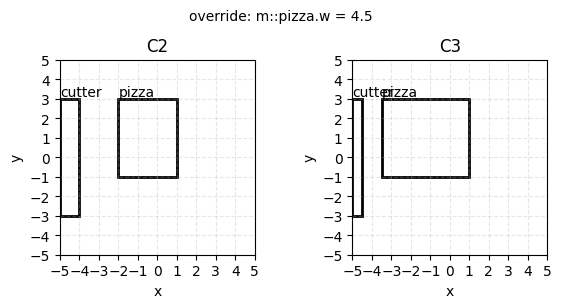

In [ ]:
p = programs[3]
print(p.pretty())

# apply normally (mparams = fixed vars read from C2)
c3 = p.apply(c2)

# override a fixed mparam to preview hypothetical edits
ovr_mpr, ovr_val = "m::pizza.w", 4.5
c3_alt = p.apply(c2, {ovr_mpr: ovr_val})
plot_c2_c3_pair(c2, c3_alt, title=f"override: {ovr_mpr} = {ovr_val}", bounds=(-5, 5, -5, 5))

In [ ]:
census

{(('cutter.h', Fraction(6, 1)),
  ('cutter.w', Fraction(1, 1)),
  ('cutter.x', Fraction(-5, 1)),
  ('cutter.y', Fraction(3, 1)),
  ('pizza.h', Fraction(4, 1)),
  ('pizza.w', Fraction(3, 1)),
  ('pizza.x', Fraction(-3, 1)),
  ('pizza.y',
   Fraction(3, 1))): [ProgramProvenance(eq_indices=(9,), fixed_vars=('cutter.w',), program_text="Equations:\n  - + cutter.w + cutter.x - pizza.x + 1 = + 0\nΔ (changed in C1→C2): ('cutter.x',)\nFixed vars F (C ∪ F'): ('cutter.w', 'cutter.x')\n  Const vars C (Δ∩V): ('cutter.x',)\n  Overridable fixed vars F': ('cutter.w',)\nDriven vars D: ('pizza.x',)\nmparams (override knobs):\n  m::cutter.w  (represents cutter.w)\noutputs:\n  cutter.w = + m::cutter.w\n  cutter.x = - 5\n  pizza.x = + m::cutter.w - 4")],
 (('cutter.h', Fraction(6, 1)),
  ('cutter.w', Fraction(2, 1)),
  ('cutter.x', Fraction(-5, 1)),
  ('cutter.y', Fraction(3, 1)),
  ('pizza.h', Fraction(4, 1)),
  ('pizza.w', Fraction(3, 1)),
  ('pizza.x', Fraction(-2, 1)),
  ('pizza.y',
   Fraction(3, 1)))

In [ ]:
programs, census = enumerate_repair_programs_and_c3s(
    c1, c2,
    eq_pool=eq_pool,
    chosen_eq_indices=None,         # means "all"
    max_system_size=3,
    max_extra_fixed=2,
    enumerate_all_parameterizations=True,
    render=False,
    take_census=False,
    bounds=(-5, 5, -5, 5),
)


=== STATS ===
systems_total                  2951
systems_considered             2951
systems_with_V                 2951
systems_pruned_no_delta_overlap 987
systems_kept_after_prune       1964
fixed_sets_total               25703
compile_attempts               25703
compile_succeeded              2812
apply_calls                    2812
c3_insertions                  2812
compile_failed                 22891

=== TIMINGS (sec) ===
0-precompute_envs              0.000491
1-enumerate_systems            0.002011
2a-support_vars                0.002103
2b-prune_by_delta_overlap      0.001126
2c-enumerate_fixed_sets        0.008008
2d-compile_repair_program      0.522826
2e-apply_program               0.061235
2f-key_and_store               0.094931


In [ ]:
a, b = list(census.items())[1]
print(len(b))
print(b[4].program_text)

923
Equations:
  - + cutter.x - pizza.x + 2 = + 0
Δ (changed in C1→C2): ('cutter.x',)
Fixed vars F (C ∪ F'): ('cutter.x',)
  Const vars C (Δ∩V): ('cutter.x',)
  Overridable fixed vars F': ()
Driven vars D: ('pizza.x',)
mparams (override knobs):
outputs:
  cutter.x = - 5
  pizza.x = - 3


In [ ]:
print(programs[30].pretty())

Equations:
  - + cutter.h - 2*cutter.y = + 0
  - + cutter.w + cutter.x - pizza.x + 1 = + 0
Δ (changed in C1→C2): ('cutter.x',)
Fixed vars F (C ∪ F'): ('cutter.w', 'cutter.x', 'cutter.y')
  Const vars C (Δ∩V): ('cutter.x',)
  Overridable fixed vars F': ('cutter.w', 'cutter.y')
Driven vars D: ('cutter.h', 'pizza.x')
mparams (override knobs):
  m::cutter.w  (represents cutter.w)
  m::cutter.y  (represents cutter.y)
outputs:
  cutter.h = + 2*m::cutter.y
  cutter.w = + m::cutter.w
  cutter.x = - 5
  cutter.y = + m::cutter.y
  pizza.x = + m::cutter.w - 4
